# 4.3 回测绩效指标全解析

## 学习目标
- 理解和计算常用回测绩效指标
- 区分不同指标的适用场景
- 了解过拟合与样本外测试的重要性

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['figure.figsize'] = (13, 5)

# 模拟策略收益数据
np.random.seed(42)
n = 252 * 5  # 5年
# 策略：年化8%，波动10%
daily_ret = np.random.normal(0.08 / 252, 0.10 / np.sqrt(252), n)
strat_returns = pd.Series(daily_ret,
    index=pd.bdate_range('2019-01-01', periods=n))

print('模拟收益数据生成 ✅')

模拟收益数据生成 ✅


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 核心绩效指标

In [3]:
def compute_metrics(returns, risk_free=0.04):
    """全面计算回测绩效指标"""
    n = len(returns)
    
    # 基础指标
    total_ret = (1 + returns).prod() - 1
    annual_ret = (1 + total_ret) ** (252 / n) - 1
    annual_vol = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio
    sharpe = (annual_ret - risk_free) / annual_vol
    
    # Sortino Ratio（只惩罚负向波动）
    downside_ret = returns[returns < 0]
    downside_vol = downside_ret.std() * np.sqrt(252)
    sortino = (annual_ret - risk_free) / downside_vol
    
    # 最大回撤
    cum = (1 + returns).cumprod()
    rolling_max = cum.cummax()
    drawdown = (cum - rolling_max) / rolling_max
    mdd = drawdown.min()
    
    # 最大回撤持续时间
    dd_duration = (drawdown < 0).astype(int)
    dd_groups = (dd_duration.diff() != 0).cumsum()
    max_dd_days = dd_duration.groupby(dd_groups).sum().max()
    
    # Calmar Ratio
    calmar = annual_ret / abs(mdd)
    
    # 胜率
    win_rate = (returns > 0).mean()
    
    # 盈亏比
    avg_win = returns[returns > 0].mean()
    avg_loss = returns[returns < 0].mean()
    profit_factor = abs(avg_win / avg_loss)
    
    return {
        '总收益率': f'{total_ret:.2%}',
        '年化收益率': f'{annual_ret:.2%}',
        '年化波动率': f'{annual_vol:.2%}',
        '夏普比率': f'{sharpe:.2f}',
        'Sortino比率': f'{sortino:.2f}',
        '最大回撤': f'{mdd:.2%}',
        '最大回撤天数': f'{max_dd_days} 天',
        'Calmar比率': f'{calmar:.2f}',
        '日胜率': f'{win_rate:.2%}',
        '盈亏比': f'{profit_factor:.2f}',
    }

metrics = compute_metrics(strat_returns)
pd.Series(metrics, name='策略绩效').to_frame()

,策略绩效
总收益率,96.98%
年化收益率,14.52%
年化波动率,9.90%
夏普比率,1.06
Sortino比率,1.87
最大回撤,-11.72%
最大回撤天数,393 天
Calmar比率,1.24
日胜率,54.13%
盈亏比,1.06


## 2. 回撤曲线可视化

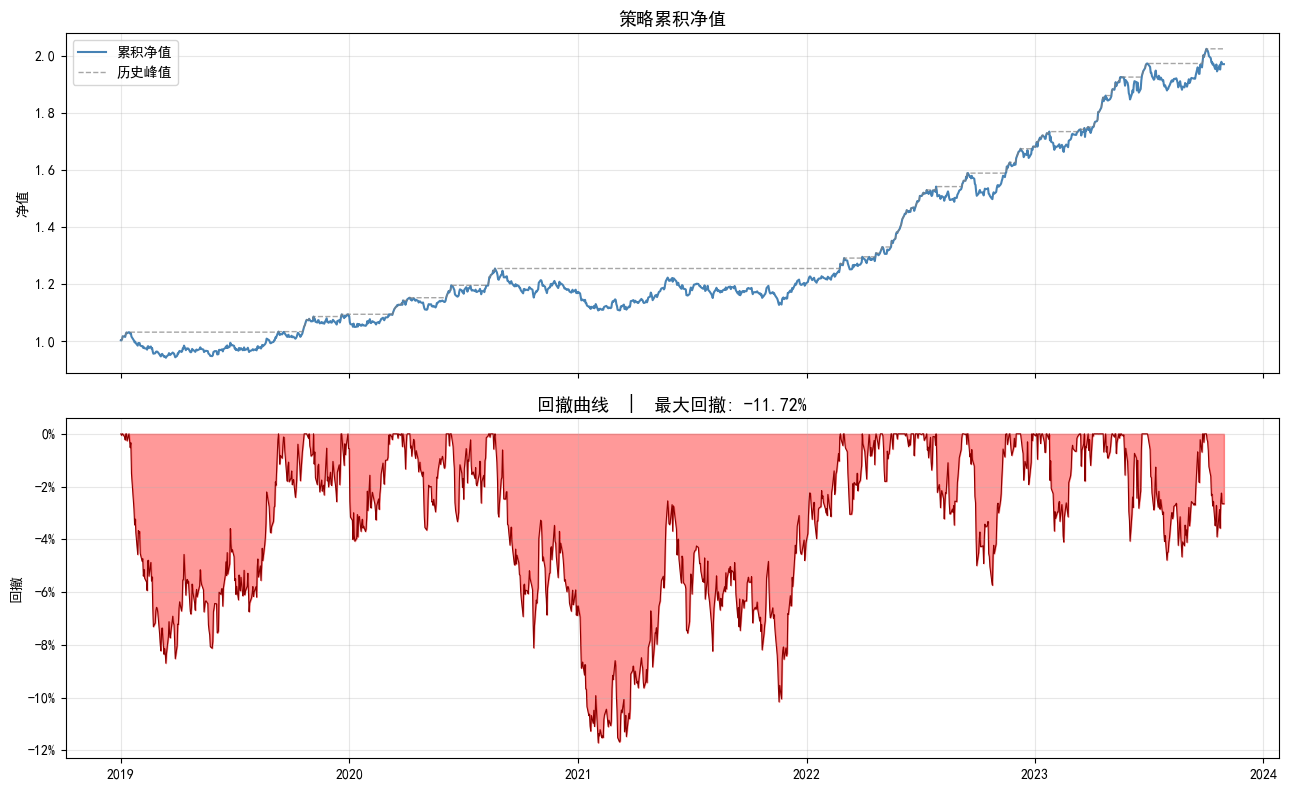

In [4]:
cum = (1 + strat_returns).cumprod()
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.plot(cum.index, cum.values, color='steelblue', linewidth=1.5, label='累积净值')
ax1.plot(rolling_max.index, rolling_max.values, color='gray',
          linewidth=1, linestyle='--', label='历史峰值', alpha=0.7)
ax1.set_title('策略累积净值', fontsize=13)
ax1.set_ylabel('净值')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.4)
ax2.plot(drawdown.index, drawdown.values, color='darkred', linewidth=0.8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.set_title(f'回撤曲线  |  最大回撤: {drawdown.min():.2%}', fontsize=13)
ax2.set_ylabel('回撤')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 样本内 vs 样本外测试（Walk-Forward）

过拟合是量化策略的最大敌人。正确做法：**训练集（in-sample）找规律，测试集（out-of-sample）验证。**

In [5]:
# 模拟样本内/外分割
split = int(len(strat_returns) * 0.7)  # 70% 训练，30% 测试
in_sample = strat_returns.iloc[:split]
out_sample = strat_returns.iloc[split:]

in_metrics = compute_metrics(in_sample)
out_metrics = compute_metrics(out_sample)

comparison = pd.DataFrame({
    '样本内 (70%)': in_metrics,
    '样本外 (30%)': out_metrics,
})
print('样本内 vs 样本外绩效对比：')
print('（若样本外明显变差，说明策略过拟合！）')
comparison

样本内 vs 样本外绩效对比：
（若样本外明显变差，说明策略过拟合！）


,样本内 (70%),样本外 (30%)
总收益率,34.75%,46.19%
年化收益率,8.89%,28.81%
年化波动率,9.82%,10.04%
夏普比率,0.50,2.47
Sortino比率,0.90,4.13
最大回撤,-11.72%,-5.74%
最大回撤天数,393 天,62 天
Calmar比率,0.76,5.02
日胜率,52.49%,57.94%
盈亏比,1.05,1.09


## 4. 月度收益热力图

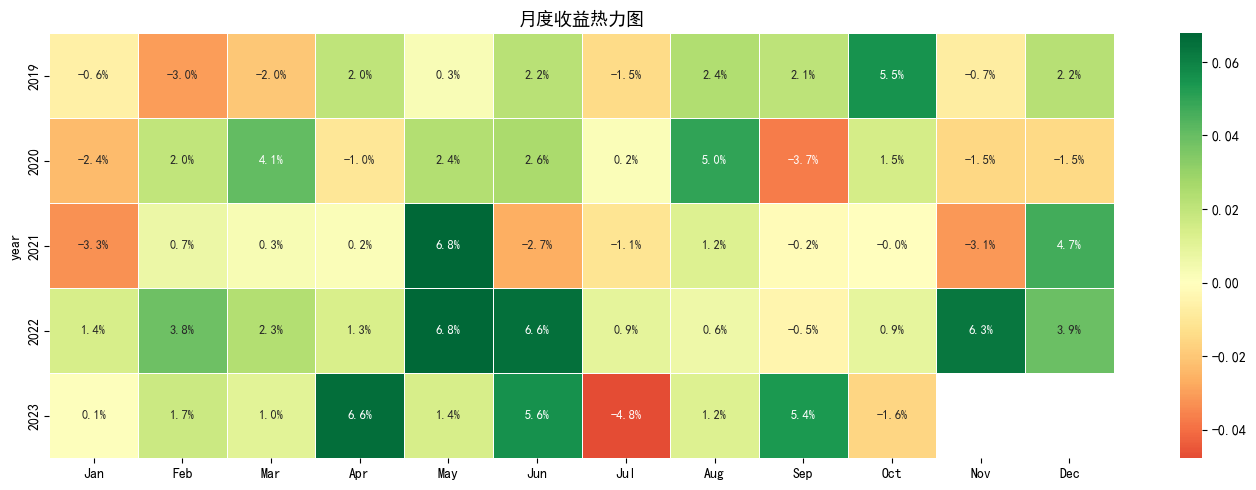

In [6]:
import seaborn as sns

monthly_ret = strat_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
monthly_df = monthly_ret.to_frame('ret')
monthly_df['year'] = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month
pivot = monthly_df.pivot(index='year', columns='month', values='ret')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                  'Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('月度收益热力图', fontsize=13)
plt.tight_layout()
plt.show()

## 🎯 练习

1. 将上方用真实 SPY 数据替换模拟数据，比较「双均线策略 vs 买入持有」的绩效指标。
2. 查阅 **Omega Ratio** 和 **Information Ratio**，在 `compute_metrics` 中实现它们。
3. 在月度热力图中，哪些月份历史上表现最差？这种规律稳定吗？（Seasonal Bias）

---
**下一模块** → `../05_portfolio/01_markowitz.ipynb`